<a href="https://colab.research.google.com/github/Bauk006/uas-bigdata-reddit-data-sience-post-kelompok2/blob/main/Project_UAS_Analisis_Dataset_Kelompok_2_Big_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd

# 1. Mengunduh dataset versi terbaru dari Kaggle
path = kagglehub.dataset_download("maksymshkliarevskyi/reddit-data-science-posts")
print("Path direktori dataset:", path)

# 2. Mencari file CSV dalam folder hasil unduhan
csv_file = None
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_file = os.path.join(path, file)
        break

print("File CSV ditemukan:", csv_file)

# 3. Memuat dataset ke dalam DataFrame Pandas
print("Memuat data ke DataFrame... (Mohon tunggu)")
df = pd.read_csv(csv_file)
print("Data berhasil dimuat!")

100%|██████████| 114M/114M [00:01<00:00, 103MB/s] 

Extracting files...


Path direktori dataset: /root/.cache/kagglehub/datasets/maksymshkliarevskyi/reddit-data-science-posts/versions/4
File CSV ditemukan: /root/.cache/kagglehub/datasets/maksymshkliarevskyi/reddit-data-science-posts/versions/4/reddit_database.csv
Memuat data ke DataFrame... (Mohon tunggu)
Data berhasil dimuat!


##Data Overview

In [ ]:
print("\n--- DATA OVERVIEW ---")

print("\nJumlah Baris dan Kolom:")
print(df.shape)

print("\nInformasi Dataset:")
print(df.info())

print("\nDaftar Kolom:")
print(df.columns.tolist())


--- DATA OVERVIEW ---

Jumlah Baris dan Kolom:
(545427, 13)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545427 entries, 0 to 545426
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   created_date           545427 non-null  object 
 1   created_timestamp      545427 non-null  float64
 2   subreddit              545427 non-null  object 
 3   title                  545427 non-null  object 
 4   id                     545427 non-null  object 
 5   author                 545427 non-null  object 
 6   author_created_utc     91985 non-null   float64
 7   full_link              545427 non-null  object 
 8   score                  545427 non-null  float64
 9   num_comments           545427 non-null  float64
 10  num_crossposts         433002 non-null  float64
 11  subreddit_subscribers  405810 non-null  float64
 12  post                   274209 non-null  object 
dtypes: float

##MISSING VALUE ANALYSIS

In [ ]:
print("\n--- MISSING VALUE ANALYSIS ---")
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage.round(2)
}).sort_values(by='Missing Percentage (%)', ascending=False)

print(missing_df)


--- MISSING VALUE ANALYSIS ---
                       Missing Count  Missing Percentage (%)
author_created_utc            453442                   83.14
post                          271218                   49.73
subreddit_subscribers         139617                   25.60
num_crossposts                112425                   20.61
created_date                       0                    0.00
id                                 0                    0.00
title                              0                    0.00
subreddit                          0                    0.00
created_timestamp                  0                    0.00
score                              0                    0.00
full_link                          0                    0.00
author                             0                    0.00
num_comments                       0                    0.00


##Unique Values

In [ ]:
print("\n--- UNIQUE VALUE ANALYSIS ---")
unique_df = pd.DataFrame({
    'Unique Values': df.nunique(),
    'Unique Ratio (%)': (df.nunique() / len(df) * 100).round(4)
}).sort_values(by='Unique Values', ascending=False)

print(unique_df)


--- UNIQUE VALUE ANALYSIS ---
                       Unique Values  Unique Ratio (%)
id                            545427          100.0000
full_link                     545427          100.0000
created_date                  544592           99.8469
created_timestamp             544592           99.8469
title                         488413           89.5469
post                          263705           48.3484
subreddit_subscribers         253311           46.4427
author                        206708           37.8984
author_created_utc             43072            7.8969
score                            592            0.1085
num_comments                     338            0.0620
subreddit                         19            0.0035
num_crossposts                     9            0.0017


##NUMERICAL DISTRIBUTION & LOW VARIANCE ANALYSIS

In [ ]:
print("\n--- NUMERICAL DISTRIBUTION & LOW VARIANCE ANALYSIS ---")

numerical_cols = ['score', 'num_comments', 'num_crossposts', 'subreddit_subscribers']
print(df[numerical_cols].describe())

for col in numerical_cols:
    unique_ratio = df[col].nunique() / len(df)
    print(f"\nKolom: {col}")
    print(f"Jumlah Unique Value: {df[col].nunique()}")
    print(f"Unique Ratio: {unique_ratio:.6f}")
    print(df[col].describe())


--- NUMERICAL DISTRIBUTION & LOW VARIANCE ANALYSIS ---
               score   num_comments  num_crossposts  subreddit_subscribers
count  545427.000000  545427.000000   433002.000000           4.058100e+05
mean        3.927306       3.749374        0.004566           3.717642e+05
std        24.602288      12.081218        0.091358           5.621793e+05
min         0.000000      -1.000000        0.000000           1.000000e+00
25%         1.000000       0.000000        0.000000           4.851525e+04
50%         1.000000       1.000000        0.000000           1.337970e+05
75%         1.000000       3.000000        0.000000           3.976270e+05
max      8331.000000    2927.000000       23.000000           2.418635e+06

Kolom: score
Jumlah Unique Value: 592
Unique Ratio: 0.001085
count    545427.000000
mean          3.927306
std          24.602288
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        8331.000000
Name: score, dtype: flo

## Persiapan Library NLP (Text Mining)

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Mengunduh komponen standard NLP dari NLTK
nltk.download('stopwords')
nltk.download('punkt')

# Inisialisasi Stemmer dan Stopwords (Bahasa Inggris karena data Reddit)
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

print("Library NLP dan Konfigurasi Preprocessing Siap!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Library NLP dan Konfigurasi Preprocessing Siap!


##Proses Text Preprocessing (Pembersihan Teks)

In [ ]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Lowercasing
    text = text.lower()

    # 2. Punctuation & Number Removal (Hanya menyisakan huruf a-z dan spasi)
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenisasi dasar pecahan kata
    words = text.split()

    # 4. Stopwords Removal & Stemming (Mengubah kata ke bentuk dasar)
    cleaned_words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(cleaned_words)

print("Mempersiapkan penggabungan kolom teks teks...")
# Gabungkan title dan post untuk memaksimalkan fitur teks yang dianalisis
df['full_text'] = df['title'].fillna('') + ' ' + df['post'].fillna('')

# Menerapkan fungsi ke seluruh baris data
# CATATAN: Karena data mencapai 545.427 baris, proses apply() ini akan memakan waktu sekitar 3-7 menit di Colab.
print("Memulai proses Text Preprocessing pada 540k+ data. Harap tunggu...")
df['clean_text'] = df['full_text'].apply(preprocess_text)
print("Text Preprocessing Selesai!")

# Menampilkan sampel hasil sebelum dan sesudah pembersihan
display(df[['full_text', 'clean_text']].head())

Mempersiapkan penggabungan kolom teks teks...
Memulai proses Text Preprocessing pada 540k+ data. Harap tunggu...
Text Preprocessing Selesai!


,full_text,clean_text
0,YouTube's traffic data for music questioned,youtub traffic data music question
1,November Sees Number of U.S. Videos Viewed Onl...,novemb see number us video view onlin surpass ...
2,So what do you guys all do related to analytic...,guy relat analyt interest there lot reason wan...
3,10 Web Analytics Tools For Tracking Your Visit...,web analyt tool track visitor
4,Improving Your Sense of Site,improv sens site


##Visualisasi Word Cloud (Kualitas Data Deskriptif)


--- VISUALISASI WORD CLOUD KESELURUHAN ---


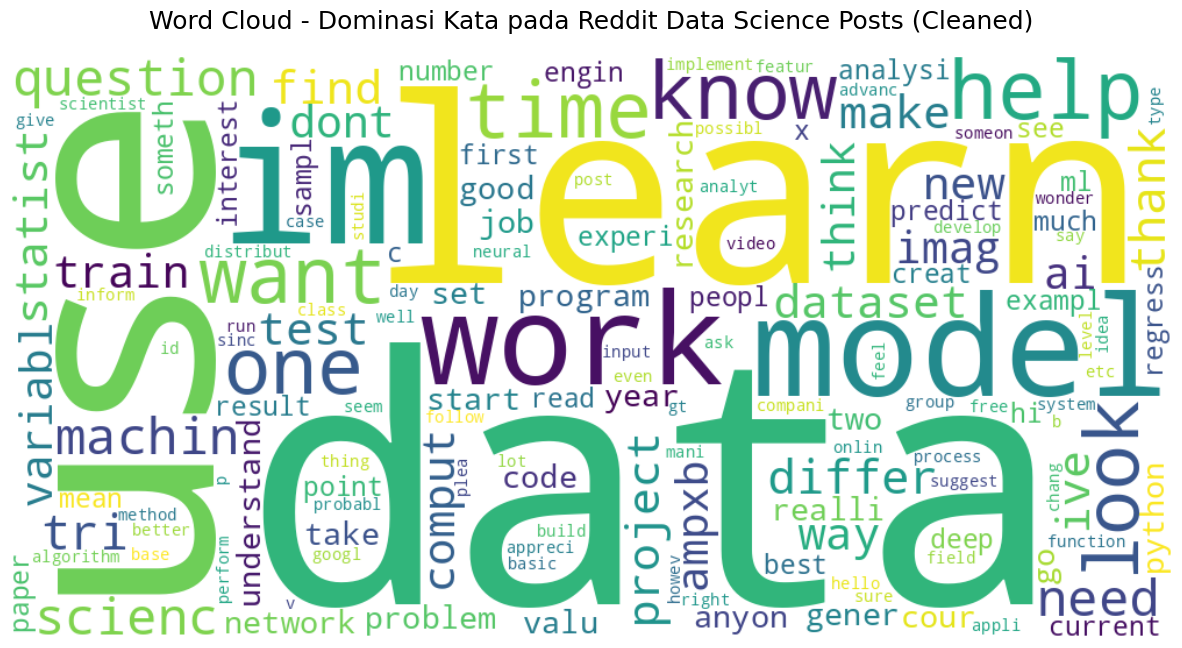

In [ ]:
print("\n--- VISUALISASI WORD CLOUD KESELURUHAN ---")

# Menggabungkan seluruh teks yang sudah bersih menjadi satu string raksasa
all_text = ' '.join(df['clean_text'])

# Membuat konfigurasi grafik WordCloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=150,          # Membatasi hanya 150 kata teratas agar rapi
    collocations=False      # Menghindari pengulangan frasa ganda berlebih
).generate(all_text)

# Menampilkan grafik menggunakan Matplotlib
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Mematikan garis sumbu koordinat x dan y
plt.title('Word Cloud - Dominasi Kata pada Reddit Data Science Posts (Cleaned)', fontsize=18, pad=20)
plt.show()

##Ekspor Data yang Sudah Bersih ke CSV Baru

In [ ]:
print("--- PROSES EKSPOR DATA ---")

# 1. Menentukan nama file CSV baru yang sudah bersih
nama_file_csv_baru = 'reddit_data_science_posts_cleaned.csv'

# 2. Mengekspor DataFrame (df) yang sudah memiliki kolom 'clean_text' ke file CSV
# index=False digunakan agar nomor indeks baris tidak ikut terbuat menjadi kolom baru
df.to_csv(nama_file_csv_baru, index=False)
print(f"Berhasil membuat file: {nama_file_csv_baru}")

# 3. Kode khusus Google Colab untuk otomatis mendownload file tersebut ke komputer/laptop Anda
from google.colab import files
print("Memulai proses unduhan ke komputer Anda... Harap tunggu hingga pop-up download muncul.")
files.download(nama_file_csv_baru)

--- PROSES EKSPOR DATA ---
Berhasil membuat file: reddit_data_science_posts_cleaned.csv
Memulai proses unduhan ke komputer Anda... Harap tunggu hingga pop-up download muncul.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>